# One dimensional dummy problem

## Problem Statement

In this section the goal will be to solve the 1 dimensional dummy problem for a first step to pressure gradients

\begin{equation}
\begin{aligned}
\rho \partial_t v &=-RT\partial_x\rho+\mu\partial_x^2 v \\
\partial_t\rho&=-\partial_x (\rho v)
\end{aligned}
\end{equation}

under IC:

\begin{equation}
\left\{ \begin{aligned}
\rho(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}

and BC:
\begin{equation}
\left\{\begin{aligned}
\rho(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
v(L,t) &= 0
\end{aligned}\right.
\end{equation}

We will expand $\rho$, and $v$ as:

\begin{equation}
    \begin{aligned}
    \rho(x,t) &= \sum_i \rho_i(t) \phi^i(x) \\
    v(x,t) &= \sum_j v_j(t) \phi^j(x)
    \end{aligned}
\end{equation}

with our solutionvector:

\begin{equation}
    \mathbf u = \begin{pmatrix}
    \rho_1 \\ \vdots \\ \rho_{N_1} \\ v_1 \\ \vdots \\ v_{N_2}
    \end{pmatrix}
\end{equation}

### Mathematical Discretizations

If we look at the top part equation and multiply by test functions $\phi^k$, integrate and expand as above, we get:

\begin{equation}
    \sum_j\left(\sum_i\rho_i\int_\Omega \phi^i\phi^j\phi^k\,dx\right)(\partial_t \mathbf{u})
\end{equation}

Which becomes:

\begin{equation}
    M\dot{\mathbf{u}}
\end{equation}

where row $k$ and column $j$ correspond to:

\begin{equation}
    (M_v)_{kj} = \sum_i\rho_i\int \phi^i\phi^j\phi^k\,dx
\end{equation}
I plan on precalculating the integrals into a tensor:

\begin{equation}
    T_{ijk} = \int \phi^i\phi^j\phi^k\,dx
\end{equation}
simplifying:
\begin{equation}
(M_v)_{kj}=\sum_i \rho_iT_{ijk}
\end{equation}

For the RHS of the first equation we get (after integration and multiplying by $\phi^k$) term for term:

\begin{equation}
\begin{aligned}
    -RT\sum_i\left(\int \phi^k\phi^i\,dx\right)\rho_i &= P\mathbf{\rho}\\
    -\mu\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) v_i &= D\mathbf{v}
\end{aligned}
\end{equation}

Giving us:

\begin{equation}
    M_v(\rho) \dot{\mathbf{v}}=P\mathbf{\rho}+D\mathbf{v}
\end{equation}


Now for the conservation of mass equation, the LHS becomes:
\begin{equation}
\sum_i\left(\int\phi^i\phi^k\,dx\right)(\partial_t\rho_i)=M_\rho\dot{\mathbf{u}}
\end{equation}

and the RHS becomes:
\begin{equation}
    -\int\phi^k\partial_x(\rho v)dx = -\left[ \phi^k\rho v\right]_{x\in\delta\Omega}+\int(\partial_x\phi^k)v \rho\, dx =\mathbf{N}(\rho, v)
\end{equation}

### IMEX Scheme

Previously I had solved one with an IMEX scheme, where all linear parts were taken implicit, and non-linear parts explicit. Now we move to more advanced built-in time integrators. From:

\begin{equation}
\begin{aligned}
M_v(\rho)\dot{v}&=P\rho+Dv \\
M_{\rho}\dot{\rho}&=N(\rho, v)+BF
\end{aligned}
\end{equation}

Is it now possible to write this as:

\begin{equation}
    M(u)\, \dot u = f(u, t)
\end{equation}

with:

$$f(u, t) = A u + g(u, t) $$

where:

\begin{equation}
\begin{aligned}
    M(u) &= \begin{pmatrix}M_\rho & 0 \\ 0 & M_v(u) \end{pmatrix} \\
    A &= \begin{pmatrix}
    0 & 0 \\
    P & D
    \end{pmatrix}\\
    g(u, t) &= \begin{pmatrix}
        N(\rho^n, v^n) \\ 0
    \end{pmatrix}\\
    (M_{\rho})_{ij}&=\int \phi^i\phi^j\,dx \\
    P_{ij} &= -RT\int\phi^i\partial_x\phi^j\,dx \\
    D_{ij} &= -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx\\
    (M_v(\rho^n))_{kj}&=\sum_i \int \rho\phi^j\phi^k\,dx\\
    (N(\rho^n, v^n))_k&=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int(\partial_x\phi^k)v\rho\,dx
\end{aligned}
\end{equation}

In [2]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

## Definitions

In [13]:
# Constants
T = 5.0;
R = 1.0;
μ = 1.0;

name = "f. fem time integration";

## grid

In [14]:
# generates 100 gridpoints between 
grid = generate_grid(Line, (100,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(2)
fr = FacetQuadratureRule{RefLine}

ip_rho = Lagrange{RefLine, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_v = Lagrange{RefLine, 1}()
cellvalues_v = CellValues(qr, ip_v);

ip_f = Lagrange{RefLine, 1}()
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)

left =  getfacetset(grid, "left")
right = getfacetset(grid, "right")

OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((100, 2))

In [15]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :rho, ip_rho)
add!(dh, :v,   ip_v)
close!(dh);

In [16]:
# constraint handler
ch = ConstraintHandler(dh)

inlet_ρ = Dirichlet(
    :rho,
    left,
    (x, t) -> 2-exp(-10*t)
)
right_v = Dirichlet(
    :v,
    right,
    (x, t) -> 0
)



add!(ch, inlet_ρ)
add!(ch, right_v)
close!(ch)
update!(ch, 0.0)

In [17]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [18]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)

                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 1 method)

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [19]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    De = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(D)
    v_dofs = dof_range(dh, :v)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(De,0)
        
        reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)

            for i in 1:n_basefuncs_v
                dpsi_i = shape_gradient(cellvalues_v, q_point, i)

                for j in 1:n_basefuncs_v
                    dpsi_j = shape_gradient(cellvalues_v, q_point, j)

                    De[v_dofs[i], v_dofs[j]] += -μ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end
    return D
end


doassemble_D! (generic function with 1 method)

$$P_{ij} = -RT\int\phi^i\partial_x\phi^j\,dx$$

In [20]:
function doassemble_P!(
    P::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    cellvalues_ρ:: CellValues,
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_ρ  = getnbasefunctions(cellvalues_ρ)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Pe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(P)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Pe,0)

        reinit!(cellvalues_v, cell)
        reinit!(cellvalues_ρ, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_ρ

                    dpsi_j = shape_gradient(cellvalues_ρ, q, j)

                    Pe[v_dofs[k], rho_dofs[j]] +=
                        -R*T * phi_k * dpsi_j[1] * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Pe)
    end
    return P
end

doassemble_P! (generic function with 1 method)

$$(M_v(\rho^n))_{kj}=\sum_i\rho_i T_{kij} $$

$$T_{ijk} = \int \phi^i\phi^j\phi^k\,dx$$

$$(M_v(\rho^n))_{kj}=\int\rho_h^n\phi^j\phi^k\,dx  $$

In [21]:
function doassemble_M_v!(
        M_v::SparseMatrixCSC,
        u::Vector{Float64},
        cellvalues_rho::CellValues,
        cellvalues_v::CellValues,
        dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    M_ve = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(M_v)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)    
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        rho_local = u[cell_dofs[rho_dofs]]

        fill!(M_ve,0)

        reinit!(cellvalues_v, cell)
        reinit!(cellvalues_rho, cell) 

        for q in 1:getnquadpoints(cellvalues_v)
            rho_q = sum(
                rho_local[j] *
                shape_value(cellvalues_rho,q,j)
                for j in 1:n_basefuncs_rho
            )

            # below alternate way that might be quicker?
            # rho_q = 0.0
            # for j in 1:n_basefuncs_rho
            #     rho_q += rho_local[j] *
            #             shape_value(cellvalues_rho,q,j)
            # end

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v
                psi_k = shape_value(
                    cellvalues_v,
                    q,
                    k
                )
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(
                        cellvalues_v,
                        q,
                        i
                    )
                        
                    M_ve[v_dofs[k], v_dofs[i]] += rho_q*psi_k*psi_i*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, M_ve)
    end
    return M_v
end

doassemble_M_v! (generic function with 1 method)

$$(N(\rho^n, v^n))_k=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx$$

$$-\big[\phi^k\rho v\big]_{\delta \Omega} = \phi^k(0)v(0)\rho(0)$$

In [22]:
function doassemble_N!(
        N::Vector{Float64},
        u::Vector{Float64},
        cellvalues_rho::CellValues,
        cellvalues_v::CellValues,
        facetvalues::FacetValues,
        left,
        dh::DofHandler
    )
    
    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    fill!(N, 0.0)

    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    for cell in CellIterator(dh)
        cell_dofs = celldofs(cell)
        rho_local = u[cell_dofs[rho_dofs]]
        v_local   = u[cell_dofs[v_dofs]]

        reinit!(cellvalues_rho, cell)
        reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_rho)

            dx = getdetJdV(cellvalues_rho, q)

            rho_q = sum(
                rho_local[j] *
                shape_value(cellvalues_rho,q,j)
                for j in 1:n_basefuncs_rho
            )
            v_q = sum(
                v_local[j] *
                shape_value(cellvalues_v,q,j)
                for j in 1:n_basefuncs_rho
            )                        
            for k in 1:n_basefuncs_rho
                dpsi_k = shape_gradient(
                    cellvalues_rho,
                    q,
                    k
                )
                N[cell_dofs[rho_dofs[k]]] += dpsi_k[1] * v_q * rho_q * dx
            end
        end
    end

    # left-boundary term: v rho ϕ^k |_{x=0}
    for facet in FacetIterator(dh, left)
        reinit!(facetvalues, facet)

        facet_dofs = facet.dofs
        rho_local = u[facet_dofs[rho_dofs]]
        v_local = u[facet_dofs[v_dofs]]

        for q in 1:getnquadpoints(facetvalues)

            dborder = getdetJdV(facetvalues, q)
            rho_q = sum(
                rho_local[j] *
                shape_value(facetvalues,q,j)
                for j in 1:n_basefuncs_rho
            )
            v_q = sum(
                v_local[j] *
                shape_value(facetvalues,q,j)
                for j in 1:n_basefuncs_v
            )               

            for k in 1:n_basefuncs_rho
                psi_k = shape_value(
                    facetvalues, 
                    q, 
                    k
                )

                N[facet_dofs[rho_dofs[k]]] += v_q * rho_q * psi_k * dborder

            end
        end         
    end
    return N 
end
    # rho_bc = 2 - exp(-10*t)
    # v_left = u[first_velocity_dof]

    # N[first_density_dof] += rho_bc * v_left



doassemble_N! (generic function with 1 method)

In [25]:
# Assemble linear matrices
M_rho = allocate_matrix(dh)
M_v   = allocate_matrix(dh)
D     = allocate_matrix(dh)
P     = allocate_matrix(dh)

# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
N      = zeros(ndofs_total)

# Calculate all matrices first. Maybe calcing M_v and M is not responsible...
doassemble_M_rho!(M_rho, cellvalues_rho, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)
doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)

# Initials I guess
M = M_rho + M_v
B = P + D

# Initial condition
apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

# Initial BC application
update!(ch, 0.0)
apply!(u, ch)

202-element Vector{Float64}:
 1.0
 1.0
 0.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 ⋮
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0
 1.0
 0.0

In [20]:
u_all = zeros(ndofs(dh), nsteps)
step_save = 0

for (step, t) in enumerate(dt:dt:T)

    # --------------------------------------------------
    # 1. Update BCs
    # --------------------------------------------------
    update!(ch, t)

    # --------------------------------------------------
    # 2. Reset nonlinear terms
    # --------------------------------------------------
    fill!(M_v, 0.0)
    fill!(N, 0.0)

    doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
    doassemble_N!(N, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh)

    # --------------------------------------------------
    # 3. Build system matrices fresh
    # --------------------------------------------------
    A = copy(A_lin)
    B = copy(B_lin)

    A .+= M_v ./ dt
    B .+= M_v ./ dt

    rhs = similar(u)
    rhs .= B * u .+ N

    # --------------------------------------------------
    # 4. Apply BCs consistently
    # --------------------------------------------------
    rhsdata = get_rhs_data(ch, A)

    A_bc = copy(A)
    rhs_bc = copy(rhs)

    apply!(A_bc, ch)
    apply_rhs!(rhsdata, rhs_bc, ch)

    # --------------------------------------------------
    # 5. Solve
    # --------------------------------------------------
    u_new = A_bc \ rhs_bc

    apply!(u_new, ch)

    # --------------------------------------------------
    # 6. Store + advance
    # --------------------------------------------------
    u = u_new
    # SAVE ONLY EVERY dt_save
    if step % save_every == 0
        step_save += 1
        u_all[:, step_save] .= u
        println(step_save*dt_save)
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [ ]:
# debugging

# --------------------------------------------------
# Assemble constant matrices
# --------------------------------------------------
M_rho = allocate_matrix(dh)
M_v   = allocate_matrix(dh)
D     = allocate_matrix(dh)
P     = allocate_matrix(dh)

doassemble_M_rho!(M_rho, cellvalues_rho, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)

A_lin = -P - D + M_rho/dt
B_lin = M_rho/dt

# --------------------------------------------------
# Initial condition
# --------------------------------------------------
ndofs_total = ndofs(dh)

u   = zeros(ndofs_total)
rhs = zeros(ndofs_total)
N   = zeros(ndofs_total)

apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

update!(ch, 0.0)
apply!(u, ch)

println("Initial u:")
display(u)

# --------------------------------------------------
# Assemble nonlinear pieces at IC
# --------------------------------------------------
fill!(M_v, 0.0)
fill!(N, 0.0)

doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v,
              facetvalues, left, dh)

println("||N|| = ", norm(N))

# --------------------------------------------------
# Build system
# --------------------------------------------------
A = copy(A_lin)
B = copy(B_lin)

A .+= M_v/dt
B .+= M_v/dt

rhs .= B*u + N

println("norm(rhs) = ", norm(rhs))

# --------------------------------------------------
# Apply BCs
# --------------------------------------------------
update!(ch, dt)

rhsdata = get_rhs_data(ch, A)

A_bc   = copy(A)
rhs_bc = copy(rhs)

apply!(A_bc, ch)
apply_rhs!(rhsdata, rhs_bc, ch)

# --------------------------------------------------
# Diagnostics
# --------------------------------------------------
println("size(A) = ", size(A_bc))
println("rank estimate = ", rank(Matrix(A_bc)))

println("minimum diag(A) = ", minimum(diag(A_bc)))
println("maximum diag(A) = ", maximum(diag(A_bc)))

# --------------------------------------------------
# Solve ONE timestep
# --------------------------------------------------
u_new = A_bc \ rhs_bc

apply!(u_new, ch)

println("max |u_new-u| = ", maximum(abs.(u_new .- u)))

# --------------------------------------------------
# Check fields separately
# --------------------------------------------------
println("rho old:")
display(u[rho_global])

println("rho new:")
display(u_new[rho_global])

println("v old:")
display(u[v_global])

println("v new:")
display(u_new[v_global])

## Plotting/animating

In [21]:
using WriteVTK

In [22]:
foldername = "debug"
filename = "two"
pvd = paraview_collection(joinpath(foldername, filename))

for (step, t) in enumerate(dt_save:dt_save:T)
    u = u_all[:, step]
    VTKGridFile(joinpath(foldername, "$(filename)-$step"), dh) do vtk
        write_solution(vtk, dh, u)
        pvd[t] = vtk
    end
end
vtk_save(pvd);

In [23]:
using Plots

[ Info: Saved animation to c:\Users\noudh\uni\MEP\3. rho time derivative\debug\flow.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\3. rho time derivative\\debug\\flow.gif")
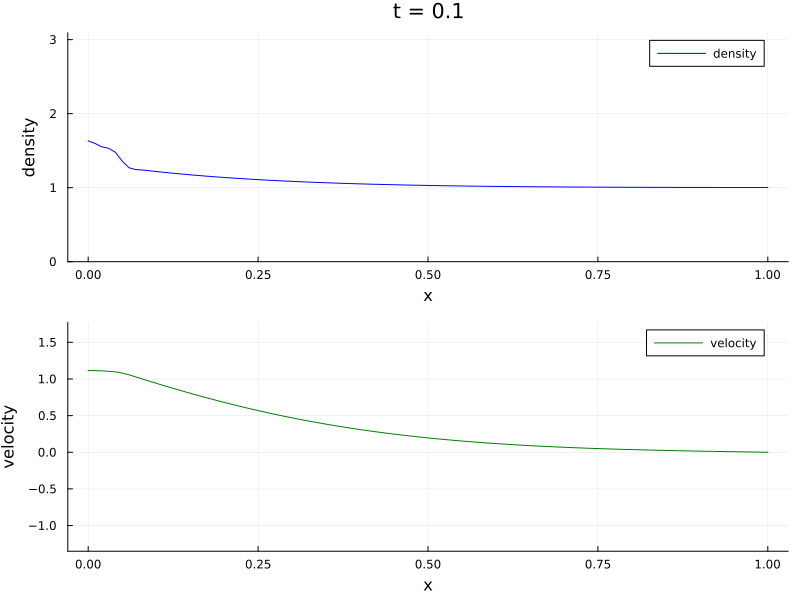

In [25]:
sol_ρ = u_all[rho_global, :]
sol_v = u_all[v_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:size(sol_ρ, 2)

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density",
        color=:blue,
        xlabel="x",
        ylabel="density",
        title="t = $(round(discrete_t[k], digits=3))",
        ylims=(0, ρmax),
        legend=:topright
    )

    p2 = plot(
        discrete_x,
        sol_v[:, k],
        label="velocity",
        color=:green,
        xlabel="x",
        ylabel="velocity",
        ylims=(vmin, vmax),
        legend=:topright
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end

gif(anim, joinpath(foldername, "flow.gif"), fps=10)

In [ ]:
rho_dofs = dof_range(dh, :rho)
v_dofs   = dof_range(dh, :v)

step = 5

rho = u_all[rho_dofs, step]
v   = u_all[v_dofs, step]

In [ ]:
rho

In [ ]:
# Plot results and compare with exact solution
discrete_x = sol[x];
discrete_t = sol[t];
sol_ρ = sol[ρ(t, x)];
sol_v = sol[v(t, x)];


folder = "b. one dimensional FEM";
mkpath(folder);

In [ ]:
# Used for plotting
using Plots

In [ ]:
ymin = 0
ymax = maximum(sol_ρ)

anim = @animate for k in 1:length(discrete_t)
    plot(
        discrete_x, 
        sol_ρ[k, :], 
        title = "Density over time", 
        ylims = (ymin, ymax), 
        ylabel = "ρ",
        xlabel = "x",
        label = "t=$(discrete_t[k])",
        legend = :bottomright
    )
end

gif(anim, joinpath(folder, "ρ.gif"), fps = 8)

In [ ]:
ymin = minimum(sol_v)
ymax = maximum(sol_v)

anim = @animate for k in 1:length(discrete_t)
    plot(
        discrete_x, 
        sol_v[k, :], 
        title = "Velocity over time", 
        ylims = (ymin, ymax), 
        ylabel = "v",
        xlabel = "x",
        label = "t=$(discrete_t[k])",
        legend = :bottomright
    )
end

gif(anim, joinpath(folder, "v.gif"), fps = 8)

### Ugly plots below

In [ ]:
plt = plot(legend = :outerright)
for i in eachindex(discrete_t)
    plot!(discrete_x, sol_ρ[i, :], label = "Numerical ρ, t=$(discrete_t[i])")
end
plt

In [ ]:
plt = plot(legend = :outerright)
for i in eachindex(discrete_t)
    plot!(discrete_x, sol_v[i, :], label = "Numerical v, t=$(discrete_t[i])")
end
plt